Fertig.


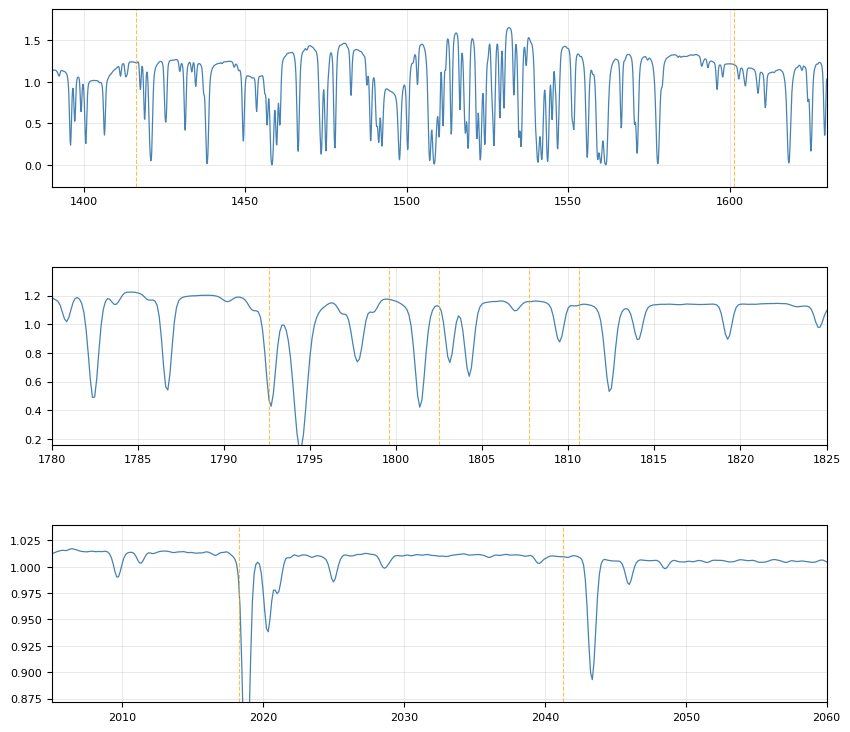

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

DATEI = "1_1_1.asc"

wn_list, it_list = [], []
with open(DATEI, "r", encoding="latin-1") as f:
    daten = False
    for zeile in f:
        z = zeile.strip()
        if z == "#DATA":
            daten = True; continue
        if daten and z:
            t = z.split()
            if len(t) == 2:
                try:
                    wn_list.append(float(t[0]))
                    it_list.append(float(t[1]))
                except ValueError:
                    pass

wn = np.array(wn_list)
it = np.array(it_list)
idx = np.argsort(wn)
wn, it = wn[idx], it[idx]

untergrund = uniform_filter1d(it, size=800)
transmission = it / untergrund

wasser_ref = [1416.08, 1601.20, 1792.65, 1799.61,
              1802.47, 1807.70, 1810.62, 2018.32, 2041.30]

bereiche = [
    (1390, 1630),
    (1780, 1825),
    (2005, 2060),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
plt.subplots_adjust(hspace=0.45)

for ax, (x1, x2) in zip(axes, bereiche):
    maske = (wn >= x1) & (wn <= x2)
    xp, yp = wn[maske], transmission[maske]
    ax.plot(xp, yp, color="steelblue", linewidth=0.9)

    # Minima
    # peaks, _ = find_peaks(-yp, prominence=0.003, distance=3)
    # ax.scatter(xp[peaks], yp[peaks], color="red", s=20, zorder=5)
    # for xi, yi in zip(xp[peaks], yp[peaks]):
    #     ax.text(xi, yi - 0.005, f"{xi:.1f}", fontsize=7,
    #             ha="center", va="top", color="red")

    # Referenzlinien
    for ref in wasser_ref:
        if x1 <= ref <= x2:
            ax.axvline(ref, color="orange", linewidth=0.8, linestyle="--", alpha=0.7)

    ax.set_xlabel("", fontsize=9)
    ax.set_ylabel("", fontsize=9)
    ax.set_xlim(x1, x2)
    p1, p99 = np.percentile(yp, [1, 99])
    m = (p99 - p1) * 0.2
    ax.set_ylim(p1 - m, p99 + m)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.tick_params(labelsize=8)

plt.savefig("wasser_simple.png",
            dpi=120, bbox_inches="tight")
print("Fertig.")

Fertig.


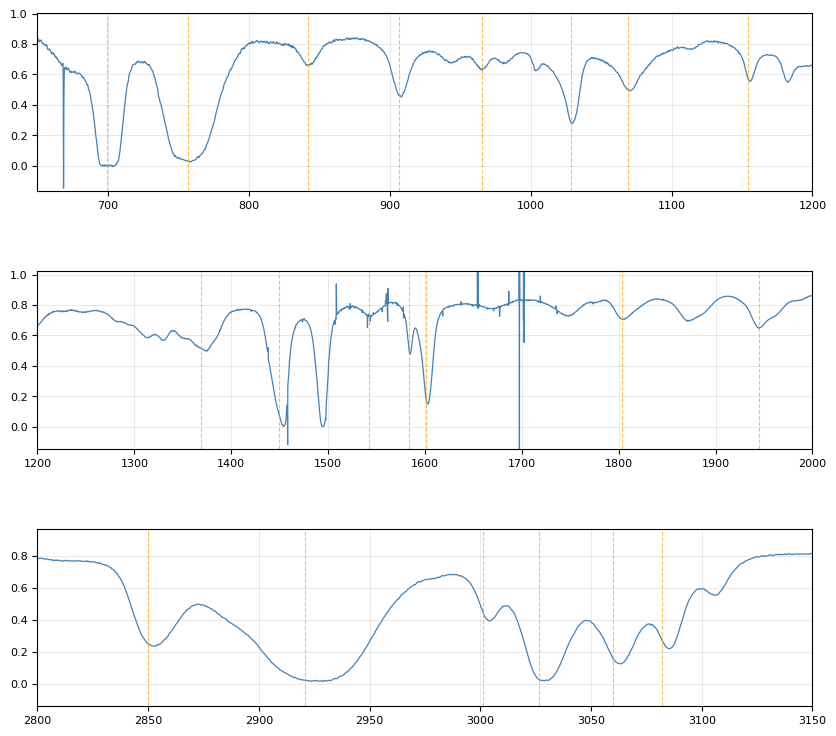

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

def lese_asc(pfad):
    wn, it = [], []
    with open(pfad, "r", encoding="latin-1") as f:
        daten = False
        for zeile in f:
            z = zeile.strip()
            if z == "#DATA":
                daten = True; continue
            if daten and z:
                t = z.split()
                if len(t) == 2:
                    try:
                        wn.append(float(t[0]))
                        it.append(float(t[1]))
                    except ValueError:
                        pass
    wn, it = np.array(wn), np.array(it)
    idx = np.argsort(wn)
    return wn[idx], it[idx]

wn_bg,   it_bg   = lese_asc("1_1_1.asc")
wn_ps,   it_ps   = lese_asc("Polysyrol.asc")

# Transmission = Probe / Background (gleiche Wellenzahlachse)
transmission = it_ps / it_bg

# Polystyrol-Referenzwellenzahlen aus der Anleitung
ps_ref = [699.45, 756.58, 842.0, 906.8, 965.7, 1028.3, 1069.1,
          1154.6, 1368.5, 1449.7, 1542.2, 1583.1, 1601.4, 1803.8,
          1945.2, 2850.0, 2920.9, 3001.4, 3026.4, 3060.0, 3082.2]

# Zoom-Bereiche passend zu den Referenzlinien
bereiche = [
    (650,  1200),
    (1200, 2000),
    (2800, 3150),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
plt.subplots_adjust(hspace=0.45)

for ax, (x1, x2) in zip(axes, bereiche):
    maske = (wn_ps >= x1) & (wn_ps <= x2)
    xp, yp = wn_ps[maske], transmission[maske]

    ax.plot(xp, yp, color="steelblue", linewidth=0.9)

    # Minima finden
    # peaks, _ = find_peaks(-yp, prominence=0.02, distance=5)
    # ax.scatter(xp[peaks], yp[peaks], color="red", s=20, zorder=5)
    # for xi, yi in zip(xp[peaks], yp[peaks]):
    #     ax.text(xi, yi - 0.01, f"{xi:.1f}", fontsize=7,
    #             ha="center", va="top", color="red")

    # Referenzlinien
    for ref in ps_ref:
        if x1 <= ref <= x2:
            ax.axvline(ref, color="orange", linewidth=0.8,
                       linestyle="--", alpha=0.7)

    ax.set_xlabel("", fontsize=9)
    ax.set_ylabel("", fontsize=9)
    ax.set_xlim(x1, x2)
    p1, p99 = np.percentile(yp, [1, 99])
    m = (p99 - p1) * 0.2
    ax.set_ylim(p1 - m, p99 + m)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.tick_params(labelsize=8)

plt.savefig("polystyrol_simple.png",
            dpi=120, bbox_inches="tight")
print("Fertig.")